# 238. Delimitation against structure search, on pre-transfer regions (experiment 2)

The claim to test: for domains shorter than half their protein, sequence-only region calls
give a boundary that chain-level structure search cannot. That is a claim about the shape
of the raw calls, before any family label is transferred, so it is scored on each tool's
region intervals directly against the human Pfam instances of the searched queries:

* **covered**: some significant region overlaps at least half the domain;
* **delimited**: some significant region has IoU >= 0.5 with the domain;
* **IoU given a hit**: the IoU of every significant region with the domain it overlaps,
  which is the distribution that separates a region-shaped call from a chain-shaped one.

Significant means E <= 1e-3 for the comparison tools and region Poisson score >= 3
(p <= 1e-3) for kmerseek. The x-axis is the domain's length as a fraction of its protein
(notebook 226's axis). hmmscan is not in the region tables; phmmer and HHblits are on the
figure and are expected to win, which is the concession that makes the structure-search
comparison credible.

**Pilot only.** The region tables on this machine are the midi-plus MHC extract: 255
queries from the MHC window (676 Pfam instances, immunoglobulin-heavy) and a subset of
kmerseek arms. The script that computes the table
(`scripts/delimitation_pre_transfer.py`) takes the full run's region files once they are
pulled from Sherlock; the figure below is the shape of the result, not the number.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

sys.path.insert(0, str(Path.cwd()))
import hp_conservation_utils as hc

pl.Config.set_tbl_rows(60)
pl.Config.set_tbl_width_chars(220)
FIG = Path("../figures")
D = Path("/Users/olga/data/qfo-pfam-region-midi-plus")
dom = pl.read_parquet(D / "238_delimitation_pre_transfer_mhc.parquet")
hits = pl.read_parquet(D / "238_delimitation_pre_transfer_mhc.hits.parquet")
ARMS = {"kmerseek.hp_pbotc_1st_ed2_k19_lcTrue": ("kmerseek hp_pbotc k19", "#a50f15"), "kmerseek.hp_thomas_dill2_k26_lcTrue": ("kmerseek hp_thomas_dill k26", "#e6550d"),
        "kmerseek.protein20_k10_lcTrue": ("kmerseek protein20 k10", "#fd8d3c"), "foldseek": ("Foldseek", "#2ca02c"), "prostt5": ("ProstT5", "#8c564b"), "reseek": ("Reseek", "#98df8a"),
        "hmmer3_phmmer": ("phmmer", "#6baed6"), "hhblits": ("HHblits", "#1f77b4"), "mmseqs2_iterative": ("MMseqs2 iter.", "#756bb1")}
FRAC_BINS = [0, 0.25, 0.5, 0.75, 1.01]; FRAC_LABELS = ["<25%", "25-50%", "50-75%", ">=75%"]
dom = dom.with_columns(((pl.col("domain_end") - pl.col("domain_start")) / pl.col("protein_length")).alias("frac")).with_columns(pl.col("frac").cut(FRAC_BINS[1:-1], labels=FRAC_LABELS).alias("frac_bin"))
print(dom.filter(pl.col("arm") == "hmmer3_phmmer").group_by("frac_bin").len().sort("frac_bin"))
summary = dom.filter(pl.col("arm").is_in(list(ARMS))).group_by("arm").agg(pl.col("covered").mean(), pl.col("delimited").mean(), pl.len()).sort("delimited", descending=True)
print(summary.with_columns(pl.col("covered").round(3), pl.col("delimited").round(3)))

shape: (4, 2)
┌──────────┬─────┐
│ frac_bin ┆ len │
│ ---      ┆ --- │
│ cat      ┆ u32 │
╞══════════╪═════╡
│ 25-50%   ┆ 99  │
│ 50-75%   ┆ 53  │
│ <25%     ┆ 480 │
│ >=75%    ┆ 44  │
└──────────┴─────┘
shape: (9, 4)
┌─────────────────────────────────┬─────────┬───────────┬─────┐
│ arm                             ┆ covered ┆ delimited ┆ len │
│ ---                             ┆ ---     ┆ ---       ┆ --- │
│ str                             ┆ f64     ┆ f64       ┆ u32 │
╞═════════════════════════════════╪═════════╪═══════════╪═════╡
│ mmseqs2_iterative               ┆ 0.979   ┆ 0.814     ┆ 676 │
│ hmmer3_phmmer                   ┆ 0.987   ┆ 0.8       ┆ 676 │
│ hhblits                         ┆ 0.976   ┆ 0.726     ┆ 676 │
│ prostt5                         ┆ 0.987   ┆ 0.572     ┆ 676 │
│ kmerseek.hp_thomas_dill2_k26_l… ┆ 0.586   ┆ 0.561     ┆ 676 │
│ kmerseek.hp_pbotc_1st_ed2_k19_… ┆ 0.561   ┆ 0.533     ┆ 676 │
│ foldseek                        ┆ 0.951   ┆ 0.493     ┆ 676 │
│ reseek      

## 1. Covered and delimited recall by domain length fraction

shape: (9, 5)
┌─────────────────────────────────┬────────┬────────┬───────┬───────┐
│ arm                             ┆ 25-50% ┆ 50-75% ┆ <25%  ┆ >=75% │
│ ---                             ┆ ---    ┆ ---    ┆ ---   ┆ ---   │
│ str                             ┆ f64    ┆ f64    ┆ f64   ┆ f64   │
╞═════════════════════════════════╪════════╪════════╪═══════╪═══════╡
│ foldseek                        ┆ 0.828  ┆ 0.943  ┆ 0.333 ┆ 0.932 │
│ hhblits                         ┆ 0.758  ┆ 0.962  ┆ 0.673 ┆ 0.955 │
│ hmmer3_phmmer                   ┆ 0.869  ┆ 0.981  ┆ 0.752 ┆ 0.955 │
│ kmerseek.hp_pbotc_1st_ed2_k19_… ┆ 0.364  ┆ 0.491  ┆ 0.606 ┆ 0.159 │
│ kmerseek.hp_thomas_dill2_k26_l… ┆ 0.404  ┆ 0.491  ┆ 0.633 ┆ 0.205 │
│ kmerseek.protein20_k10_lcTrue   ┆ 0.202  ┆ 0.377  ┆ 0.171 ┆ 0.091 │
│ mmseqs2_iterative               ┆ 0.889  ┆ 0.981  ┆ 0.767 ┆ 0.955 │
│ prostt5                         ┆ 0.879  ┆ 0.943  ┆ 0.44  ┆ 0.886 │
│ reseek                          ┆ 0.525  ┆ 0.962  ┆ 0.056 ┆ 0.955 │
└─────

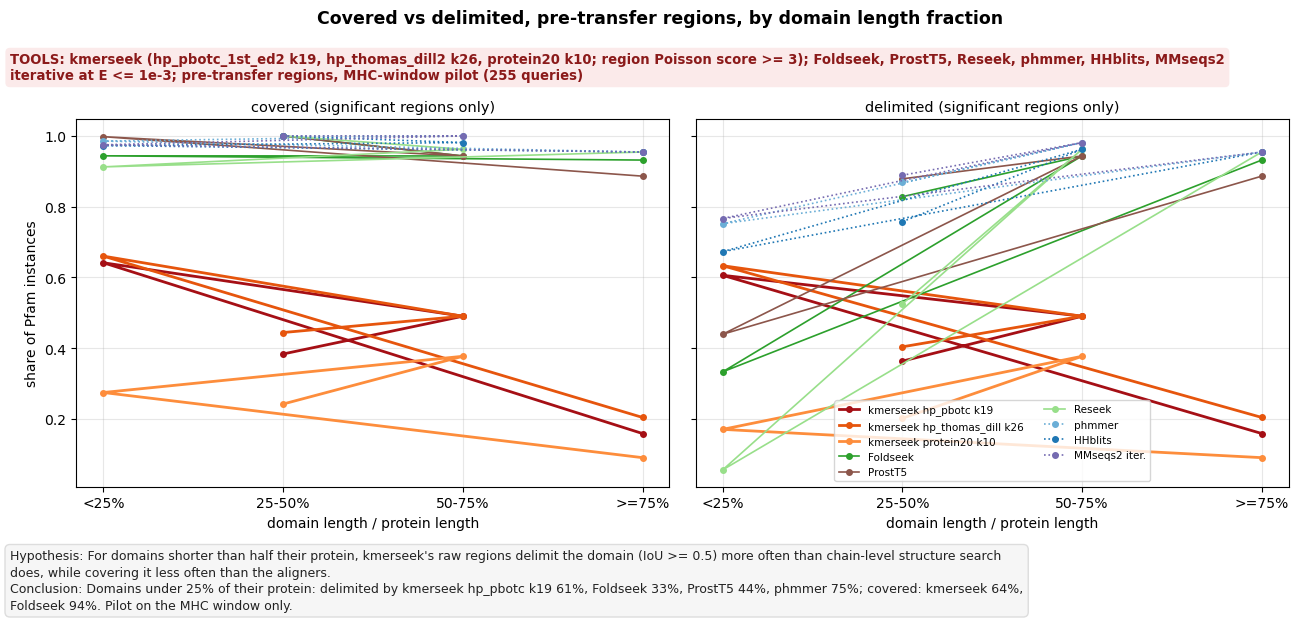

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), sharey=True)
for ax, metric in zip(axes, ["covered", "delimited"]):
    for arm, (lab, col) in ARMS.items():
        s = dom.filter(pl.col("arm") == arm).group_by("frac_bin").agg(pl.col(metric).mean()).sort("frac_bin")
        ax.plot([FRAC_LABELS.index(b) for b in s["frac_bin"]], s[metric], marker="o", ms=4, color=col, lw=2 if arm.startswith("kmerseek") else 1.2, ls="-" if arm.startswith("kmerseek") or arm in ("foldseek", "prostt5", "reseek") else ":", label=lab)
    ax.set_xticks(range(len(FRAC_LABELS)), FRAC_LABELS)
    ax.set_xlabel("domain length / protein length")
    ax.set_title(f"{metric} (significant regions only)", fontsize=10.5)
    ax.grid(alpha=0.3)
axes[0].set_ylabel("share of Pfam instances")
axes[1].legend(fontsize=7.5, ncol=2)
tab = dom.filter(pl.col("arm").is_in(list(ARMS))).group_by("arm", "frac_bin").agg(pl.col("covered").mean().round(3), pl.col("delimited").mean().round(3), pl.len()).sort("arm", "frac_bin")
print(tab.pivot(on="frac_bin", index="arm", values="delimited"))
def v(arm, b, m="delimited"):
    x = dom.filter((pl.col("arm") == arm) & (pl.col("frac_bin") == b))[m]
    return x.mean() if x.len() else float("nan")
hc.finish_figure(
    fig, FIG / "238_covered_delimited_by_length_fraction.png",
    tools="kmerseek (hp_pbotc_1st_ed2 k19, hp_thomas_dill2 k26, protein20 k10; region Poisson score >= 3); Foldseek, ProstT5, Reseek, phmmer, HHblits, MMseqs2 iterative at E <= 1e-3; pre-transfer regions, MHC-window pilot (255 queries)",
    hypothesis="For domains shorter than half their protein, kmerseek's raw regions delimit the domain (IoU >= 0.5) more often than chain-level structure search does, while covering it less often than the aligners.",
    conclusion=(f"Domains under 25% of their protein: delimited by kmerseek hp_pbotc k19 {100 * v('kmerseek.hp_pbotc_1st_ed2_k19_lcTrue', '<25%'):.0f}%, Foldseek {100 * v('foldseek', '<25%'):.0f}%, ProstT5 {100 * v('prostt5', '<25%'):.0f}%, phmmer {100 * v('hmmer3_phmmer', '<25%'):.0f}%; "
                f"covered: kmerseek {100 * v('kmerseek.hp_pbotc_1st_ed2_k19_lcTrue', '<25%', 'covered'):.0f}%, Foldseek {100 * v('foldseek', '<25%', 'covered'):.0f}%. Pilot on the MHC window only."),
    title="Covered vs delimited, pre-transfer regions, by domain length fraction",
)

## 2. IoU given a hit: the shape of the calls

/var/folders/rl/81r400y52z38l8_kwn4g1xdc0000gn/T/ipykernel_20639/4012675725.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[ARMS[a][0] for a in order], showfliers=False, patch_artist=True, widths=0.6)


shape: (9, 4)
┌─────────────────────────────────┬────────────┬──────────────────┬─────────┐
│ arm                             ┆ median_iou ┆ share_iou_ge_0.5 ┆ hits    │
│ ---                             ┆ ---        ┆ ---              ┆ ---     │
│ str                             ┆ f64        ┆ f64              ┆ u32     │
╞═════════════════════════════════╪════════════╪══════════════════╪═════════╡
│ kmerseek.hp_thomas_dill2_k26_l… ┆ 0.196      ┆ 0.084            ┆ 203256  │
│ mmseqs2_iterative               ┆ 0.176      ┆ 0.204            ┆ 419920  │
│ hmmer3_phmmer                   ┆ 0.173      ┆ 0.103            ┆ 574914  │
│ prostt5                         ┆ 0.17       ┆ 0.182            ┆ 802191  │
│ kmerseek.hp_pbotc_1st_ed2_k19_… ┆ 0.152      ┆ 0.05             ┆ 3674413 │
│ foldseek                        ┆ 0.151      ┆ 0.179            ┆ 535962  │
│ hhblits                         ┆ 0.122      ┆ 0.069            ┆ 838501  │
│ kmerseek.protein20_k10_lcTrue   ┆ 0.1        ┆ 0

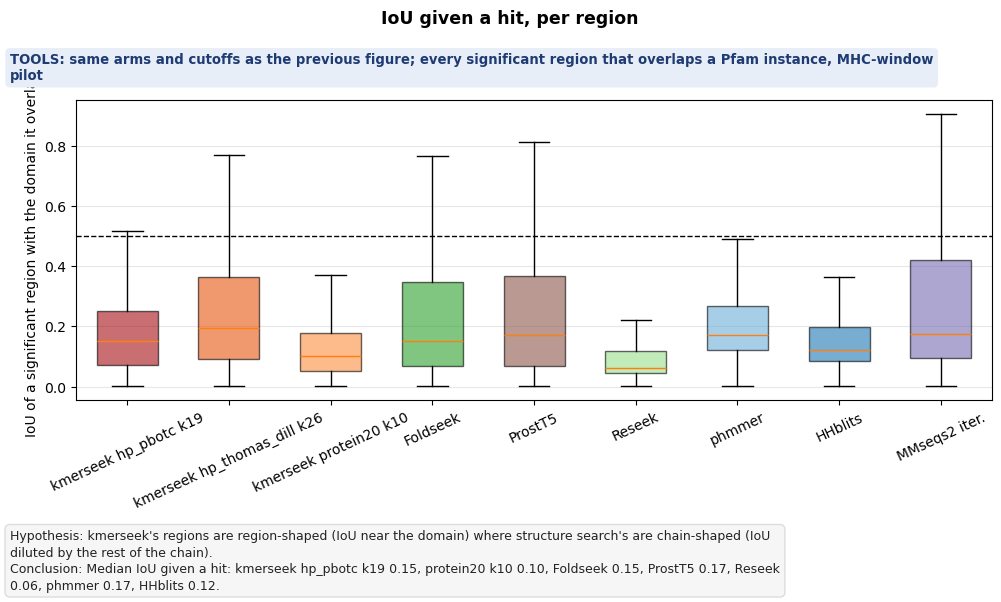

In [3]:
fig, ax = plt.subplots(figsize=(10, 4.4))
order = [a for a in ARMS if a in hits["arm"].unique().to_list()]
data = [hits.filter(pl.col("arm") == a)["iou"].to_numpy() for a in order]
bp = ax.boxplot(data, labels=[ARMS[a][0] for a in order], showfliers=False, patch_artist=True, widths=0.6)
for patch, a in zip(bp["boxes"], order):
    patch.set_facecolor(ARMS[a][1]); patch.set_alpha(0.6)
ax.axhline(0.5, color="k", ls="--", lw=1)
ax.set_ylabel("IoU of a significant region with the domain it overlaps")
ax.tick_params(axis="x", rotation=25)
ax.grid(axis="y", alpha=0.3)
med = hits.filter(pl.col("arm").is_in(order)).group_by("arm").agg(pl.col("iou").median().round(3).alias("median_iou"), (pl.col("iou") >= 0.5).mean().round(3).alias("share_iou_ge_0.5"), pl.len().alias("hits")).sort("median_iou", descending=True)
print(med)
m = {r["arm"]: r for r in med.iter_rows(named=True)}
def mi(a):
    return m[a]["median_iou"] if a in m else float("nan")
hc.finish_figure(
    fig, FIG / "238_iou_given_hit.png",
    tools="same arms and cutoffs as the previous figure; every significant region that overlaps a Pfam instance, MHC-window pilot",
    hypothesis="kmerseek's regions are region-shaped (IoU near the domain) where structure search's are chain-shaped (IoU diluted by the rest of the chain).",
    conclusion=(f"Median IoU given a hit: kmerseek hp_pbotc k19 {mi('kmerseek.hp_pbotc_1st_ed2_k19_lcTrue'):.2f}, protein20 k10 {mi('kmerseek.protein20_k10_lcTrue'):.2f}, Foldseek {mi('foldseek'):.2f}, ProstT5 {mi('prostt5'):.2f}, Reseek {mi('reseek'):.2f}, phmmer {mi('hmmer3_phmmer'):.2f}, HHblits {mi('hhblits'):.2f}."),
    title="IoU given a hit, per region",
)

## 3. To run on the full set

```bash
rsync -az "sherlock:/scratch/users/olgabot/2024-kmerseek-analysis/nextflow-runs/qfo-pfam-region-benchmark/data/midi-plus/results/regions/" /Users/olga/data/qfo-pfam-region-midi-plus/regions/
```

then point `scripts/delimitation_pre_transfer.py --kmerseek ... --baseline ...` at region
tables assembled from that directory (one file per arm x species; the extract's two
tables are the concatenation with `species`, `alphabet`, `ksize`, `lc` / `tool` columns
added). The figures above regenerate from the resulting parquet.